# BERT Base Multilingual Uncased Sentiment Classifier

**Load all the required libraries**

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as pl
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import pandas as pd
import re

**Load dataset and filter the individual shows**

In [2]:
# load original dataset
df = pd.read_csv('/Users/anthonykamau/Desktop/reddit_data.csv')

# got filters
df_got = df[(df["title"] == "Game of Thrones") & (df["year"] == 2017)]

# better call saul filters
df_bcs = df[(df["title"] == "Better Call Saul") & (df["year"] == 2020)]

**Pre-processing function**

In [13]:
def clean_text(text):
    # Remove zero‑width spaces (HTML encoded)
    text = re.sub(r'&#x200B;', ' ', text)

    # Remove Reddit system markers
    text = re.sub(r'\[removed\]\[deleted\]', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Collapse multiple spaces / newlines
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df_got["clean_post"] = df_got["post"].astype(str).apply(clean_text)
df_bcs["clean_post"] = df_bcs["post"].astype(str).apply(clean_text)
#df_combined["clean_post"] = df_combined["post"].astype(str).apply(clean_text)

In [ ]:
# delete empty rows in clean_post
df_got = df_got[df_got["clean_post"].str.strip() != ""]

# delete rows in clean_post that contain 'removed' or 'deleted'
df_bcs = df_bcs[~df_bcs ["clean_post"].str.contains(r'\b(removed|deleted)\b', case=False, na=False)]

In [16]:
df_bcs.head(20)

,Unnamed: 0,title,type,year,post,clean_post
6,6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, t...","Maybe when Jimmy gets the $7 million to ABQ, t..."
13,13,Better Call Saul,linear,2020,He was an assistant manager/manager. Definitel...,He was an assistant manager/manager. Definitel...
21,21,Better Call Saul,linear,2020,I thought that the writers / producers consult...,I thought that the writers / producers consult...
23,23,Better Call Saul,linear,2020,"Good point. My bad.\n\nStill, when hey made it...","Good point. My bad. Still, when hey made it, h..."
25,25,Better Call Saul,linear,2020,Didnt Howard help him get that gig?,Didnt Howard help him get that gig?
46,46,Better Call Saul,linear,2020,Work and she might be going away very soon. As...,Work and she might be going away very soon. As...
49,49,Better Call Saul,linear,2020,The phonecall Francesca takes on Nov 12th (Jim...,The phonecall Francesca takes on Nov 12th (Jim...
54,54,Better Call Saul,linear,2020,I think he's just pissed he's having to do thi...,I think he's just pissed he's having to do thi...
57,57,Better Call Saul,linear,2020,Piggybacking off this comment to say the creat...,Piggybacking off this comment to say the creat...
61,61,Better Call Saul,linear,2020,"""Take my true love by the hand, lead her throu...","""Take my true love by the hand, lead her throu..."


**Initiate the Bertbase tokenizer and build the model**

In [17]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english", use_fast=True)

model = AutoModelForSequenceClassification.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

**Create a function for performing batch sentiment analysis**

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


def batch_sentiment(posts, batch_size=256, max_length=64):
    all_scores = []

    for i in range(0, len(posts), batch_size):
        batch = posts[i:i+batch_size].tolist()

        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            output = model(**tokens)

        scores = torch.argmax(output.logits, dim=1)
        all_scores.extend(scores.cpu().tolist())

    return all_scores

**Derive the sentiments using the batch sentiment function and create a new column called 'sentiments'**

In [19]:
# Apply sentiment analysis to the 'post' column in df_got
df_got["sentiments"] = batch_sentiment(df_got["post"])


In [20]:
df_got.to_csv(
    "/Users/anthonykamau/Desktop/text_media/df_got.csv",
    index=False
)

In [21]:
df_got.head(20)

,Unnamed: 0,title,type,year,post,sentiments,clean_post
19097,19097,Game of Thrones,linear,2017,LITTLEFINGER IS FUCKING DEAD UPVOTE PARTY,2,LITTLEFINGER IS FUCKING DEAD UPVOTE PARTY
19100,19100,Game of Thrones,linear,2017,At least it would be a reason for Samwell to p...,0,At least it would be a reason for Samwell to p...
19102,19102,Game of Thrones,linear,2017,Plot armor op please nerf.,3,Plot armor op please nerf.
19117,19117,Game of Thrones,linear,2017,Who's the big woman? Brienne?,0,Who's the big woman? Brienne?
19123,19123,Game of Thrones,linear,2017,"Oh not at all, she is fucking fine.",0,"Oh not at all, she is fucking fine."
19127,19127,Game of Thrones,linear,2017,Scene from next episode: Theon floating on his...,0,Scene from next episode: Theon floating on his...
19128,19128,Game of Thrones,linear,2017,I want someone to look at me the way that Jon ...,1,I want someone to look at me the way that Jon ...
19139,19139,Game of Thrones,linear,2017,"You were expecting Tyrion, but it was me, Olenna!",2,"You were expecting Tyrion, but it was me, Olenna!"
19141,19141,Game of Thrones,linear,2017,"""Davos the Manos"" \n\nBrilliant",0,"""Davos the Manos"" Brilliant"
19143,19143,Game of Thrones,linear,2017,Browne vs Arya is a perfect reason why dex bui...,0,Browne vs Arya is a perfect reason why dex bui...


In [22]:
df_got["sentiments"].value_counts()

sentiments
0    2360
2     917
4     286
1     225
3      98
Name: count, dtype: int64

<Axes: title={'center': 'Sentiment Distribution for Game of Thrones Posts (2017)'}, xlabel='sentiments'>

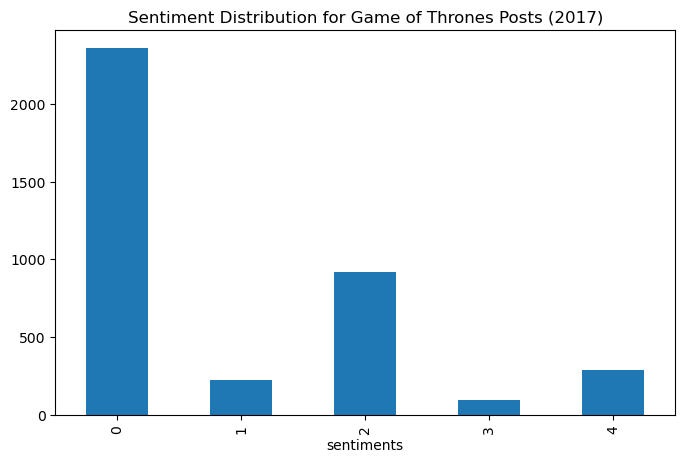

In [23]:
freq_got = df_got["sentiments"].value_counts().sort_index()
freq_got
freq_got.plot(kind="bar", figsize=(8, 5), title="Sentiment Distribution for Game of Thrones Posts (2017)")  

In [24]:
# Apply sentiment analysis to the 'post' column in df_bcs

df_bcs["sentiments"] = batch_sentiment(df_bcs["post"])

In [25]:
df_bcs.to_csv(
    "/Users/anthonykamau/Desktop/text_media/df_bcs.csv",
    index=False
)

In [27]:
df_bcs.head(20)

,Unnamed: 0,title,type,year,post,clean_post,sentiments
6,6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, t...","Maybe when Jimmy gets the $7 million to ABQ, t...",0
13,13,Better Call Saul,linear,2020,He was an assistant manager/manager. Definitel...,He was an assistant manager/manager. Definitel...,0
21,21,Better Call Saul,linear,2020,I thought that the writers / producers consult...,I thought that the writers / producers consult...,0
23,23,Better Call Saul,linear,2020,"Good point. My bad.\n\nStill, when hey made it...","Good point. My bad. Still, when hey made it, h...",0
25,25,Better Call Saul,linear,2020,Didnt Howard help him get that gig?,Didnt Howard help him get that gig?,2
46,46,Better Call Saul,linear,2020,Work and she might be going away very soon. As...,Work and she might be going away very soon. As...,0
49,49,Better Call Saul,linear,2020,The phonecall Francesca takes on Nov 12th (Jim...,The phonecall Francesca takes on Nov 12th (Jim...,0
54,54,Better Call Saul,linear,2020,I think he's just pissed he's having to do thi...,I think he's just pissed he's having to do thi...,0
57,57,Better Call Saul,linear,2020,Piggybacking off this comment to say the creat...,Piggybacking off this comment to say the creat...,0
61,61,Better Call Saul,linear,2020,"""Take my true love by the hand, lead her throu...","""Take my true love by the hand, lead her throu...",0


In [28]:
df_bcs["sentiments"].value_counts()

sentiments
0    901
2    199
4     55
1     42
3     28
Name: count, dtype: int64

<Axes: title={'center': 'Sentiment Distribution for Better Call Saul Posts (2020)'}, xlabel='sentiments'>

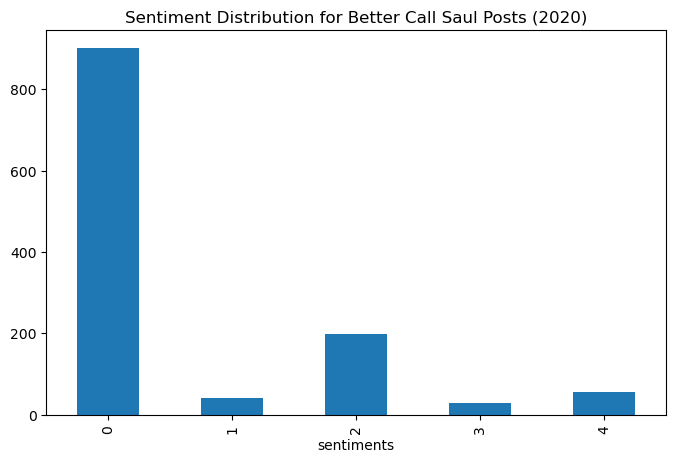

In [29]:
freq_bcs = df_bcs["sentiments"].value_counts().sort_index()
freq_bcs
freq_bcs.plot(kind="bar", figsize=(8, 5), title="Sentiment Distribution for Better Call Saul Posts (2020)")